## Image Convolutions

In [4]:
from tensorflow import keras
from tensorflow.keras import layers
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tensorflow
import PIL
from PIL import ImageOps, Image
import cv2

In [7]:
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/flower_photos.tgz"
data_dir = keras.utils.get_file(origin=dataset_url,
                                fname='flower_photos',
                                untar=True)

data_dir = pathlib.Path(data_dir)

for folder in data_dir.glob('[!LICENSE]*'):
    print('The', folder.name, 'folder has',
          len(list(folder.rglob('*.jpg'))), 'pictures')
          
image_count = len(list(data_dir.rglob('*.jpg')))
print(image_count, 'total images')

The flower_photos folder has 3670 pictures
3670 total images


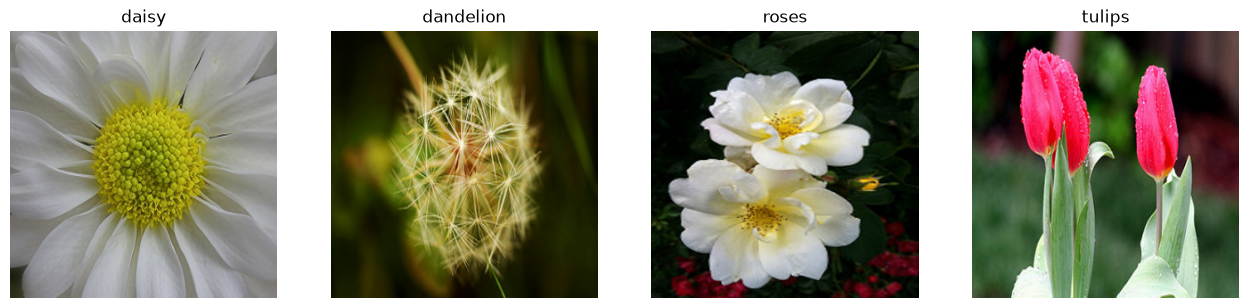

In [11]:
pics = list()
pics_arr = list()
p_class = list()

img_width = 300
img_height = 300
data_dir = data_dir / 'flower_photos'

plt.figure(figsize=(20,5))
valid_folders = [d for d in data_dir.glob('[!LICENSE]*') if d.is_dir()]

for idx, folder in enumerate(valid_folders):
    cat = list(folder.glob('*.jpg'))
    
    if not cat:
        print(f"Skipping {folder.name}: No .jpg files found.")
        continue
        
    pic = PIL.Image.open(str(cat[0])).resize((img_width, img_height))
    pic_arr = np.array(pic)
    clss = folder.name
    
    plt.subplot(1, 5, idx + 1)
    plt.imshow(pic)
    plt.title(clss)
    plt.axis('off')
    
    pics.append(pic)
    pics_arr.append(pic_arr)
    p_class.append(clss)

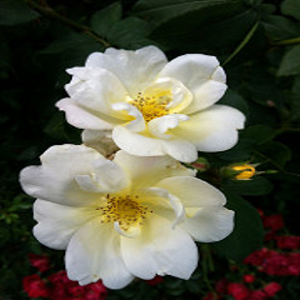

In [19]:
img = pics[2]
img

## Kernels

In [12]:
# implemenr an edge detection through funcs

def v_grad(shape, dtype=None):

    grad = np.array([
        [1, 0, -1],
        [2, 0, -2],
        [1, 0, -1]
    ]).reshape((3, 3, 1, 1))

    assert grad.shape == shape
    return keras.backend.variable(grad, dtype=np.float32)


def h_grad(shape, dtype=None):

    grad = np.array([
        [1, 2, 1],
        [0, 0, 0],
        [-1, -2, -1]
    ]).reshape(3, 3, 1, 1)

    assert grad.shape == shape
    return keras.backend.variable(grad, dtype=np.float32)

### Building the Convolutional Neural Network

Here we will build two very simple one layer convolutional neural networks, which will just apply our kernels over an input image. The definition of the function is below.

**keras.layers.Conv2d**

```python
keras.layers.convolutional.Conv2D(filters, kernel_size, strides=(1, 1), padding='valid', data_format=None, dilation_rate=(1, 1), activation=None, use_bias=True, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=None, bias_regularizer=None, activity_regularizer=None, kernel_constraint=None, bias_constraint=None, **kwargs)
```


In [16]:
input_layer = layers.Input(shape=(img_width, img_height, 1))

h_conv = layers.Conv2D(
    filters=1,   # number of kernels
    kernel_size=3,
    kernel_initializer=h_grad,
    strides=1,
    padding='valid'  # valid = no padding
)

v_conv = layers.Conv2D(
    filters=1,
    kernel_size=3,
    kernel_initializer=v_grad,
    strides=1,
    padding='valid'
)

h_model = keras.Sequential([input_layer, h_conv])
v_model = keras.Sequential([input_layer, v_conv])

In [17]:
h_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 298, 298, 1)    │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
v_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 298, 298, 1)    │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

We must convert our RGB image to grayscale, since our CNN models were only designed to apply 1 kernel to 1 channel of input.

In [25]:
gray = ImageOps.grayscale(img)

input_img = np.array(gray).reshape((1, img_width, img_height, 1))
out_d = h_model.layers[0].output.shape[1:]

Gx = h_model.predict(input_img).reshape(out_d)
Gy = v_model.predict(input_img).reshape(out_d)

G = np.hypot(Gx, Gy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


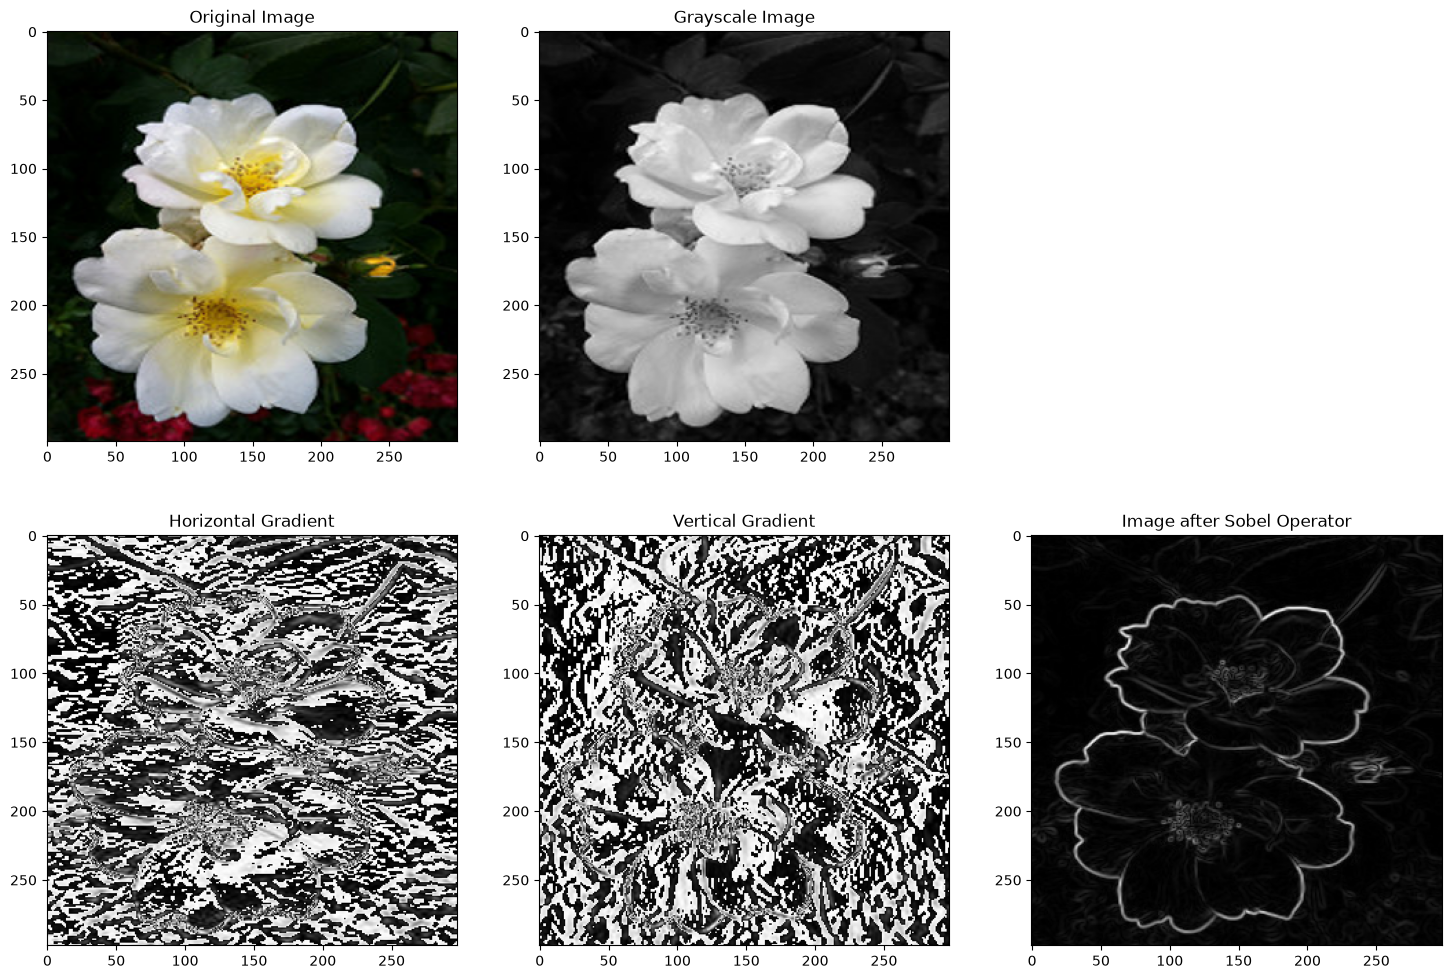

In [26]:
plt.figure(figsize=(18, 12))
plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.subplot(2, 3, 2)
plt.imshow(gray, cmap=plt.get_cmap('gray'))
plt.title("Grayscale Image")
plt.subplot(2, 3, 4)
plt.imshow(Gx.astype('uint8'), cmap=plt.get_cmap('gray'))
plt.title("Horizontal Gradient")
plt.subplot(2, 3, 5)
plt.imshow(Gy.astype('uint8'), cmap=plt.get_cmap('gray'))
plt.title("Vertical Gradient")
plt.subplot(2, 3, 6)
plt.imshow(G, cmap=plt.get_cmap('gray'))
plt.title("Image after Sobel Operator")
plt.show()

## Blob Detection

Text(0.5, 1.0, 'Image After using Difference of Gaussians')

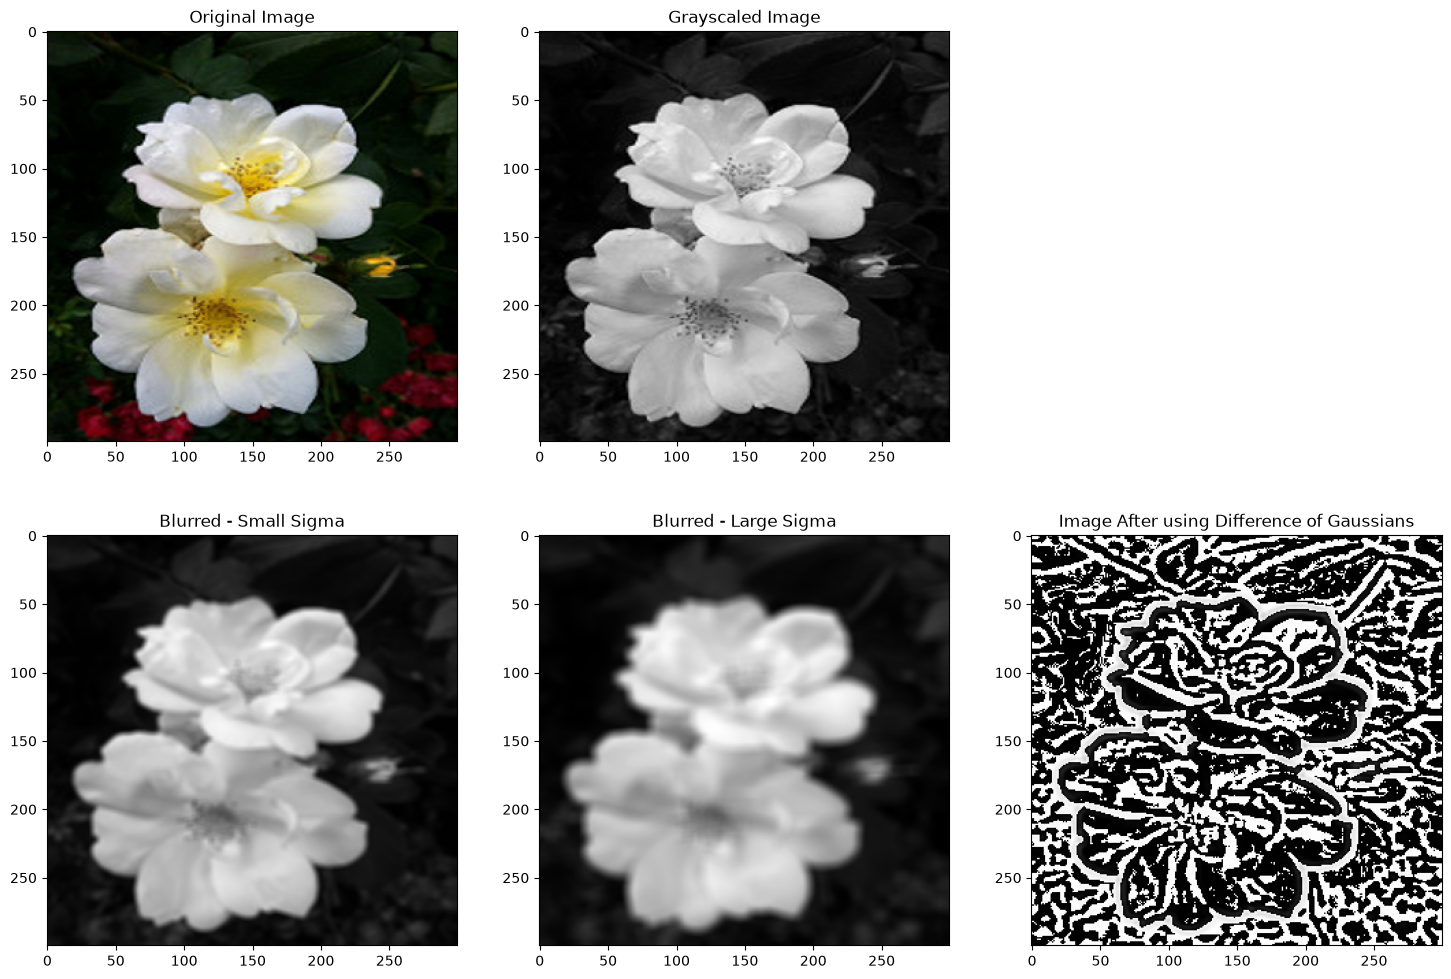

In [28]:
sigma_sm = 5
sigma_lg = 9
blurred_sm = cv2.GaussianBlur(np.array(gray), (sigma_sm, sigma_sm), sigma_sm)
blurred_lg = cv2.GaussianBlur(np.array(gray), (sigma_lg, sigma_lg), sigma_lg)

diff_of_gaussian = blurred_sm - blurred_lg

plt.figure(figsize=(18, 12))

# orig image
plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title('Original Image')

# grayscaled 
plt.subplot(2, 3, 2)
plt.imshow(np.array(gray), cmap=plt.get_cmap('gray'))
plt.title('Grayscaled Image')

# using small sigma
plt.subplot(2, 3, 4)
plt.imshow(blurred_sm.astype('uint8'), cmap=plt.get_cmap('gray'))
plt.title('Blurred - Small Sigma')

# using small sigma
plt.subplot(2, 3, 5)
plt.imshow(blurred_lg.astype('uint8'), cmap=plt.get_cmap('gray'))
plt.title('Blurred - Large Sigma')

plt.subplot(2, 3, 6)
plt.imshow(diff_of_gaussian.astype('uint8'), cmap=plt.get_cmap('gray'))
plt.title('Image After using Difference of Gaussians')